In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
# Usage
base_dir = "../experiment13[depol-time-evo-noisy_p1e-3_tmax_10]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)
EXACT_SOL: float = -8.566772233505624

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['tmax10'])

In [4]:
RAW_SIM_DATA["tmax10"].keys()

dict_keys(['ZNE', 'VQE'])

In [5]:
def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}
        
        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noiseoff", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue
        
        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (mul1, ric2, etc.) ---
        zne_folder = content.get("ZNE", {})
        
        # If mul1 is missing, ensure the key exists in the raw zne_folder
        for label, runs in zne_folder.items():
            ext_vals, all_y_curves = [], []
            noise_levels = None
            
            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run: 
                    continue
                
                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})
                
                tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]

                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                if current_y and current_n and ext_val is not None:
                    ext_vals.append(ext_val)
                    all_y_curves.append(current_y)
                    if noise_levels is None:
                        noise_levels = current_n
                else:
                    # Debug print to see which file is failing the check
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing", 
                    "tmax":           tmax,
                    "exact_sol":      EXACT_SOL, # Global variable you defined
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"]
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [6]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

dict_keys(['tmax10'])

In [7]:
PROCESSED_SIM_DATA["tmax10"]

{'ric4': {'noise_type': 'depolarizing',
  'tmax': 10.0,
  'exact_sol': -8.566772233505624,
  'sorted_noise': [13, 47, 81, 115],
  'mean_exp_vals': [-6.516684022416077,
   -3.461229599099229,
   -1.8942540239043713,
   -1.0636040589870392],
  'std_exp_vals': [0.00032875917174899846,
   0.0011674727547514253,
   0.0010986182728518405,
   0.0008117257652784714],
  'zne_mean': -8.236161298301706,
  'zne_std': 0.0008312249374889391,
  'mean_noise_off': None,
  'std_noise_off': None}}

In [8]:
# Output directory to save plot figures
OUTPUT_DIR = "master-reports"
COLORS = {
    "noisy":      "#1f77b4",
    "zne":        "#ff7f0e",
    "exact":      "#d62728",
    "noise_free": "#0000ff",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'depolarizing',
 'tmax': 10.0,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47, 81, 115],
 'mean_exp_vals': [-6.516684022416077,
                   -3.461229599099229,
                   -1.8942540239043713,
                   -1.0636040589870392],
 'std_exp_vals': [0.00032875917174899846,
                  0.0011674727547514253,
                  0.0010986182728518405,
                  0.0008117257652784714],
 'zne_mean': -8.236161298301706,
 'zne_std': 0.0008312249374889391,
 'mean_noise_off': None,
 'std_noise_off': None}


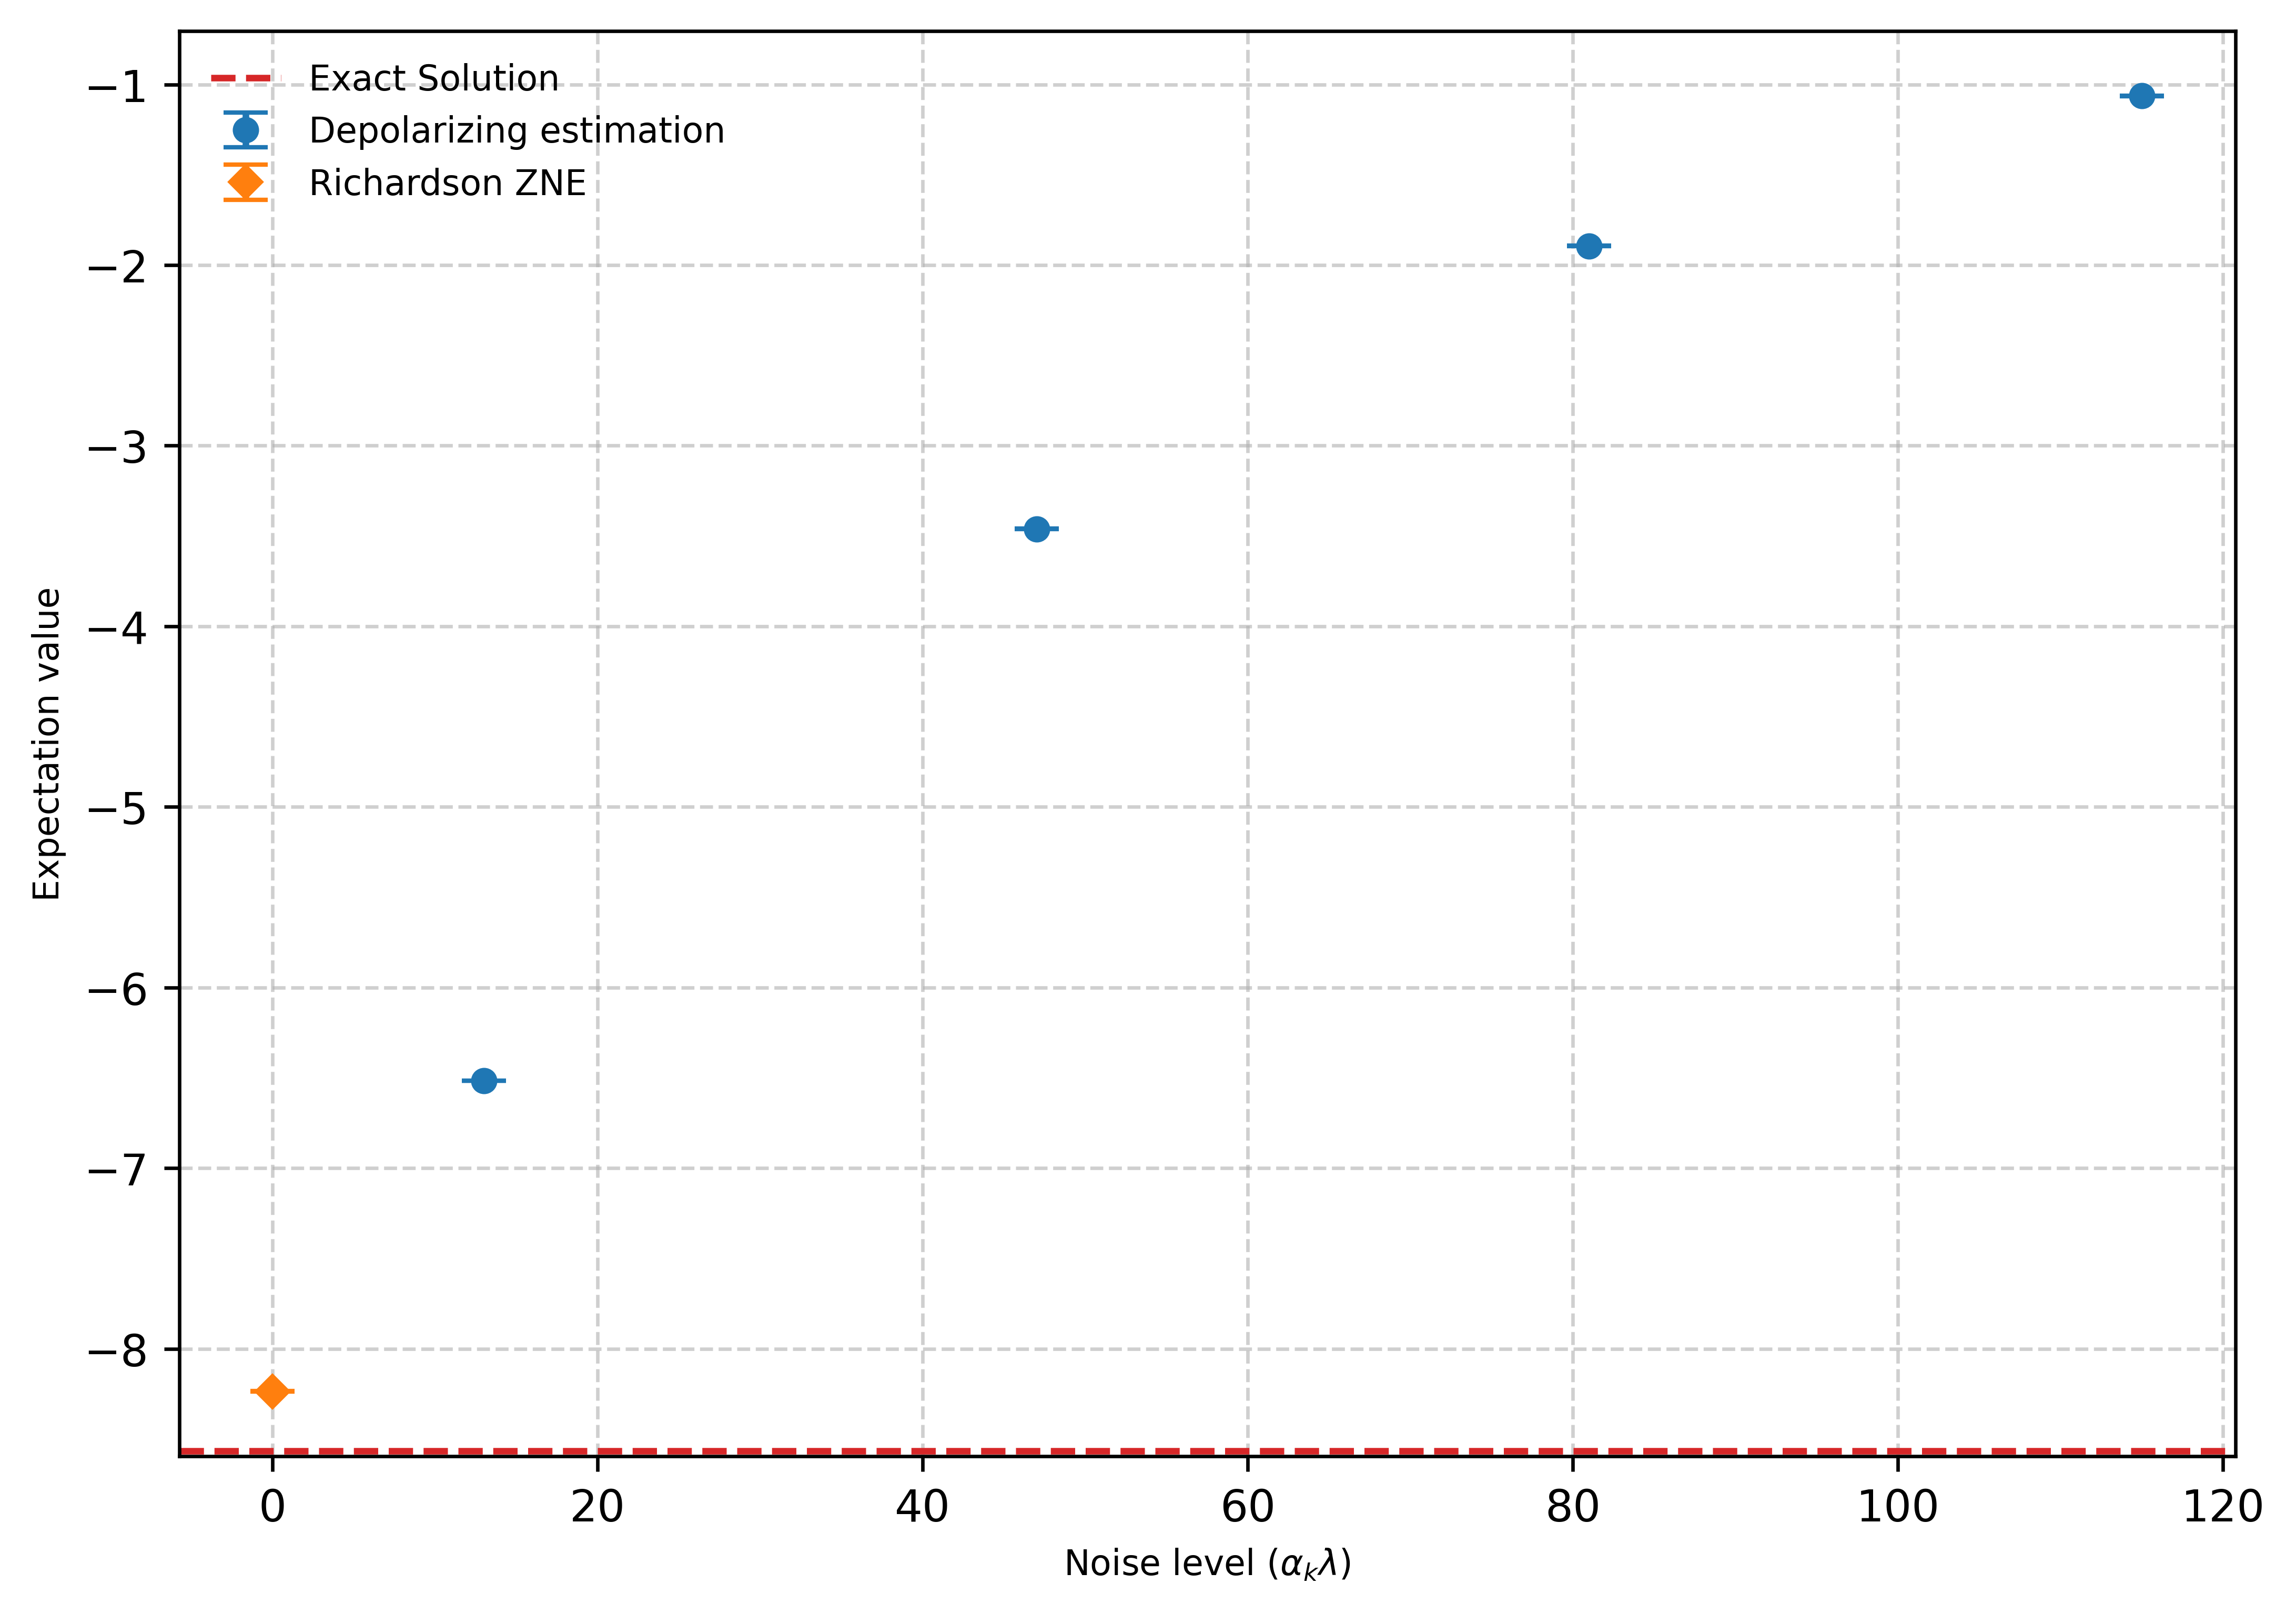

In [9]:
fig = plot_single_zne(
    data=PROCESSED_SIM_DATA["tmax10"]["ric4"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

In [10]:
def plot_zne_vs_tmax(data: dict, circuit_key: str = None):
    """
    Plot ZNE mean ± std vs tmax.

    Parameters
    ----------
    data        : PROCESSED_SIM_DATA dict  (keys like 'tmax5', 'tmax10', …)
    circuit_key : which inner key to use (e.g. 'ric4').
                  If None, uses the first key found in each tmax bucket.
    """
    tmax_vals, zne_means, zne_stds = [], [], []

    for tmax_key, inner in sorted(data.items(), key=lambda x: int(x[0].replace("tmax", ""))):
        # Pick the circuit sub-dict
        ck = circuit_key if circuit_key else next(iter(inner))
        entry = inner[ck]

        tmax_vals.append(entry["tmax"])
        zne_means.append(entry["zne_mean"])
        zne_stds.append(entry["zne_std"])

    tmax_vals = np.array(tmax_vals)
    zne_means = np.array(zne_means)
    zne_stds  = np.array(zne_stds)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.errorbar(
        tmax_vals, zne_means,
        yerr=zne_stds,
        fmt="o-",
        capsize=5,
        capthick=1.5,
        linewidth=1.8,
        markersize=7,
        color="#2563eb",
        ecolor="#93c5fd",
        elinewidth=2,
        label="ZNE mean ± std",
    )

    # Exact solution — same for all tmax, draw as a horizontal dashed line
    exact_sol = next(iter(inner.values()))["exact_sol"]
    ax.axhline(
        exact_sol,
        color="#dc2626",
        linewidth=1.8,
        linestyle="--",
        label=f"Exact solution ({exact_sol:.4f})",
    )

    ax.set_xlabel("tmax", fontsize=13)
    ax.set_ylabel("ZNE", fontsize=13)
    ax.set_title("ZNE vs tmax", fontsize=14)
    ax.set_xticks(tmax_vals)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()

    out = "zne_vs_tmax.png"
    fig.savefig(out, dpi=150)
    print(f"Saved → {out}")
    plt.show()

Saved → zne_vs_tmax.png


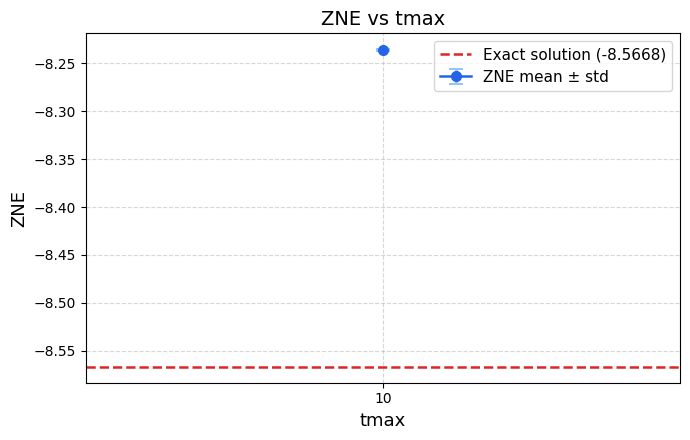

In [11]:
plot_zne_vs_tmax(PROCESSED_SIM_DATA)